## 2D Kernels

Import utils

In [4]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *

#### Kernel 1: Simple Cell

 &emsp; 1.1. Build kernel<br>

In [5]:
#np.random.seed(seed=187)

#############################
#          Params           #
#############################

N_L0_E = 1000000
N_L0_I = 1000000
N_L1_E = 3

N = (N_L0_E + N_L0_I, N_L1_E)
n = int(N_L0_E**(1/2))
sig = 0.00001
K = 1

# sig_0_E = 0.005
# sig_0_I = 0.025

# sig_1_x = 0.040
# sig_1_y = sig

sig_0_E = 0.010
sig_0_I = 0.030
sig_1_E_x = 0.040
sig_1_E_y = sig
sig_1_I_x = 0.040
sig_1_I_y = sig

kappa = 50

n_angles = 2
angles = np.linspace(0, 1, n_angles, endpoint=False) + 0.25
#angles[0] = 0.25

probs = np.full(n_angles, 1/n_angles)

p_0 = 1

w_0_E =  1.0/(N_L0_E*(1/n_angles)*np.pi*((sig_0_E)**2)*p_0) #* 2.25
w_0_I = -1.0/(N_L0_I*(1/n_angles)*np.pi*((sig_0_I)**2)*p_0) #* 2.25

#############################
#        Create Net         #
#############################

net = []

# layer 0 

# ext
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
xy_L0_E = np.column_stack((X.ravel(), Y.ravel()))
theta_L0_E = np.random.choice(angles, size=N_L0_E, p=probs) * np.pi

xy_lig_L0_E = xy_L0_E #+ sig * np.random.randn(N_L0_E, 2)
th_lig_L0_E = theta_L0_E + sig * np.random.randn(N_L0_E)

noise_theta_E = warp_coords(np.random.randn(N_L0_E, 2), theta_L0_E, sig_1_E_x, sig_1_E_y)
xy_rec_L0_E = xy_L0_E + noise_theta_E
th_rec_L0_E = theta_L0_E + sig * np.random.randn(N_L0_E)

layer_lig_L0_E = np.column_stack((xy_lig_L0_E, th_lig_L0_E))
layer_rec_L0_E = np.column_stack((xy_rec_L0_E, th_rec_L0_E))

# inh
xy_L0_I = xy_L0_E.copy()
theta_L0_I = np.random.choice(angles, size=N_L0_I, p=probs) * np.pi

xy_lig_L0_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
th_lig_L0_I = theta_L0_I + sig * np.random.randn(N_L0_I)

noise_theta_I = warp_coords(np.random.randn(N_L0_I, 2), theta_L0_I, sig_1_I_x, sig_1_I_y)
xy_rec_L0_I = xy_L0_I + noise_theta_I
th_rec_L0_I = theta_L0_I + sig * np.random.randn(N_L0_I)

layer_lig_L0_I = np.column_stack((xy_lig_L0_I, th_lig_L0_I))
layer_rec_L0_I = np.column_stack((xy_rec_L0_I, th_rec_L0_I))

layer_lig_L0_combined = np.vstack((layer_lig_L0_E, layer_lig_L0_I))
layer_rec_L0_combined = np.vstack((layer_rec_L0_E, layer_rec_L0_I))

net.append([layer_lig_L0_combined, layer_rec_L0_combined])

# layer 1

xy_L1_E = np.random.rand(N_L1_E, 2)
theta_L1_E = np.random.choice(angles, size=N_L1_E, p=probs) * np.pi
theta_L1_E[0] = 0.25*np.pi
theta_L1_E[1] = 0.75*np.pi
theta_L1_E[2] = 0.25*np.pi
xy_L1_E[0:2, 0] = xy_L1_E[0:2, 1] = 0.5
xy_L1_E[2, 0] = xy_L1_E[2, 1] = 0.75

xy_lig_L1_E = xy_L1_E + sig * np.random.randn(N_L1_E, 2)
th_lig_L1_E = theta_L1_E + sig * np.random.randn(N_L1_E)
layer_lig_L1_E = np.column_stack((xy_lig_L1_E, th_lig_L1_E))

xy_rec_L1_E = xy_L1_E + sig * np.random.randn(N_L1_E, 2)
th_rec_L1_E = theta_L1_E + sig * np.random.randn(N_L1_E)
layer_rec_L1_E = np.column_stack((xy_rec_L1_E, th_rec_L1_E))

net.append([layer_lig_L1_E, layer_rec_L1_E])

#############################
#  Create Connectivity      #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]

l_vals_L1_E = net[1][0]
r_vals_L1_E = net[1][1]

B_L0E_L1E = sample_bernoulli_sparse(
    compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E, kappa=kappa), K)
B_L0I_L1E = sample_bernoulli_sparse(
    compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I, kappa=kappa), K)

W_0_E = (w_0_E * B_L0E_L1E).tocsr()   
W_0_I = (w_0_I * B_L0I_L1E).tocsr()        

 &emsp; 1.2. Analyze kernel<br>

Index: 0
Location: x=0.500, y=0.500
Preferred Orientation: 45.0°



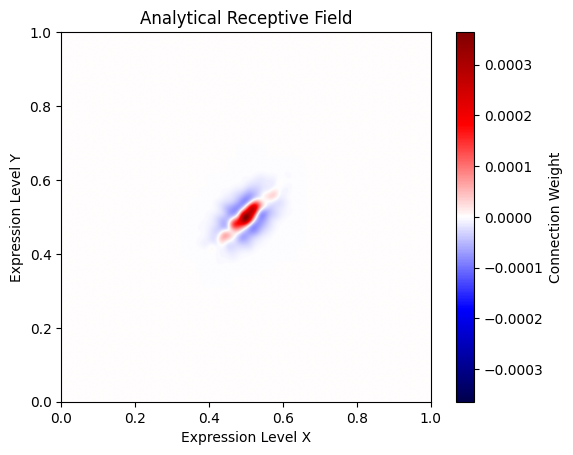

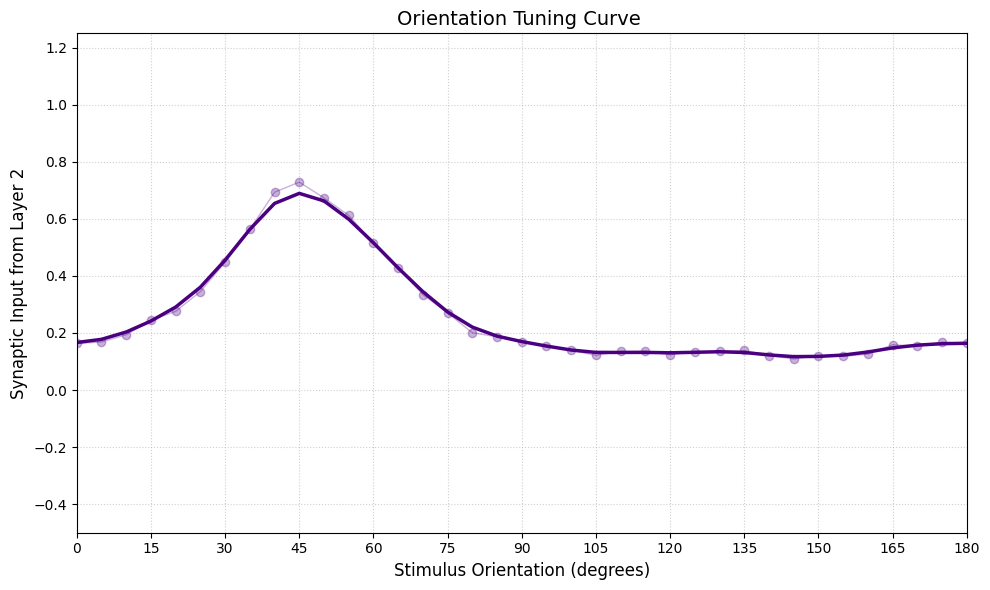

L1 index: 0
Location: x=0.500, y=0.500
Preferred Orientation: 45.0°

sf =   2.00 cyc/unit   L1 F1/F0 =    nan
sf =   2.35 cyc/unit   L1 F1/F0 =    nan
sf =   2.76 cyc/unit   L1 F1/F0 =    nan
sf =   3.24 cyc/unit   L1 F1/F0 =  1.928
sf =   3.80 cyc/unit   L1 F1/F0 =  1.797
sf =   4.46 cyc/unit   L1 F1/F0 =  1.729
sf =   5.24 cyc/unit   L1 F1/F0 =  1.684
sf =   6.15 cyc/unit   L1 F1/F0 =  1.662
sf =   7.22 cyc/unit   L1 F1/F0 =  1.640
sf =   8.47 cyc/unit   L1 F1/F0 =  1.627
sf =   9.94 cyc/unit   L1 F1/F0 =  1.620
sf =  11.67 cyc/unit   L1 F1/F0 =  1.617
sf =  13.71 cyc/unit   L1 F1/F0 =  1.619
sf =  16.09 cyc/unit   L1 F1/F0 =  1.624
sf =  18.89 cyc/unit   L1 F1/F0 =  1.638
sf =  22.17 cyc/unit   L1 F1/F0 =  1.655
sf =  26.03 cyc/unit   L1 F1/F0 =  1.698
sf =  30.56 cyc/unit   L1 F1/F0 =  1.807
sf =  35.88 cyc/unit   L1 F1/F0 =    nan
sf =  42.12 cyc/unit   L1 F1/F0 =  1.899
sf =  49.45 cyc/unit   L1 F1/F0 =  1.876
sf =  58.05 cyc/unit   L1 F1/F0 =  1.928
sf =  68.15 cyc/unit   L1 F1/

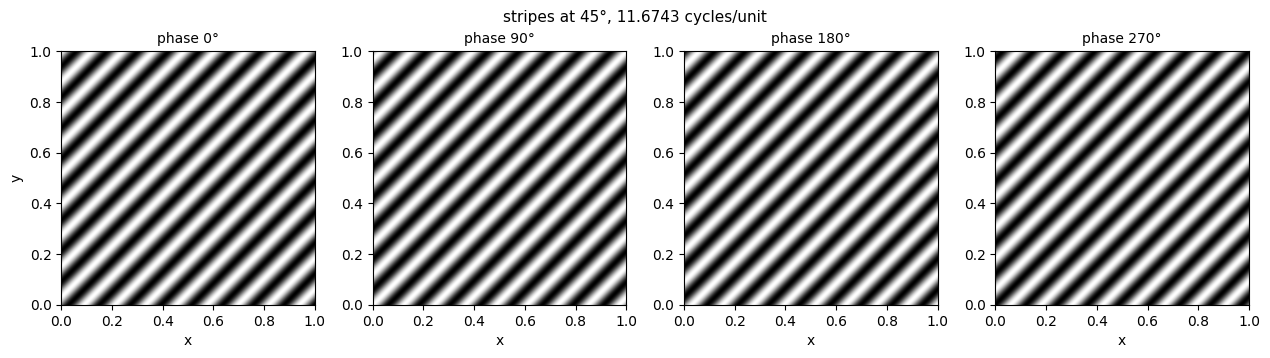

In [3]:
#############################
#       Analytical RF       #
#############################

coords = [0.5,0.5]
target_x, target_y = 0.50, 0.50
target_theta = np.radians(45)

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=10)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0

print(f"L1 index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

A_0 = np.full(N_L0_E, 0.5)
spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

best_sf, best_peak, best_L1 = None, -np.inf, None

for sf in sfs:
    resp_L1 = np.zeros(n_phase)

    for i, phase in enumerate(phases):
        A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
        A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
        resp_L1[i] = A_1[target_idx]

    L1 = f1_f0(resp_L1, spont_L1)
    print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

    if L1['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L1['peak'], L1


kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
      f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

Index: 0
Location: x=0.500, y=0.500
Preferred Orientation: 45.0°



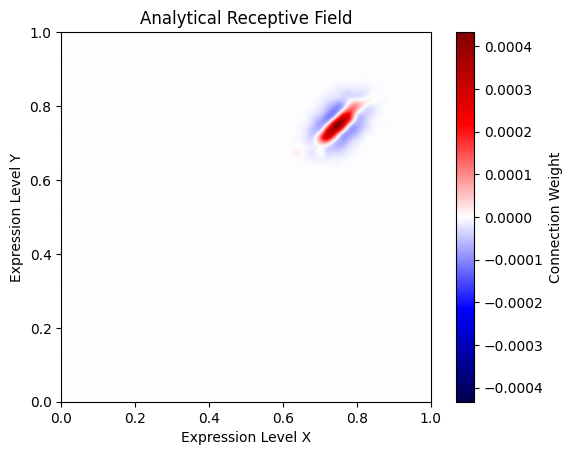

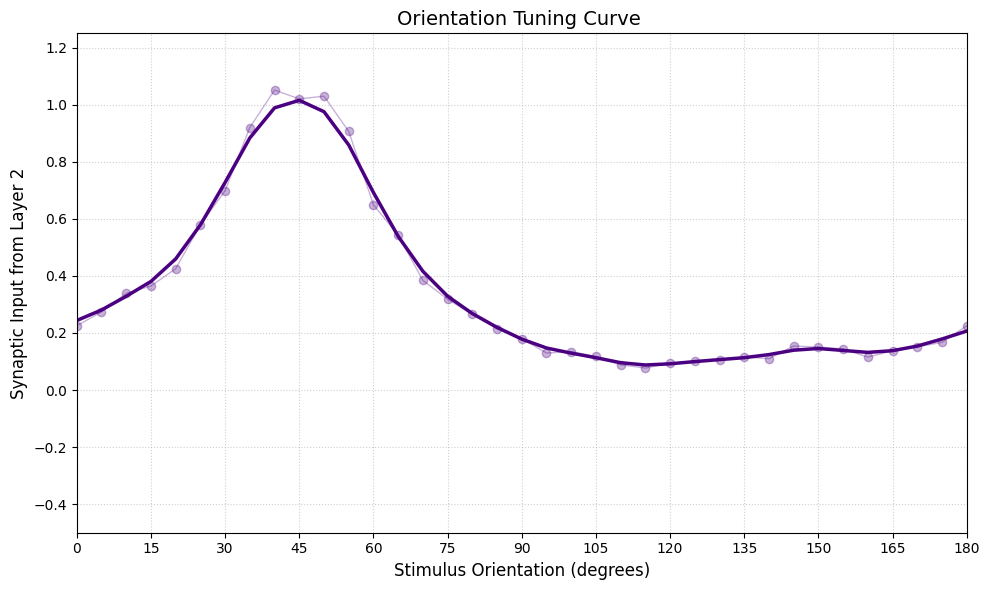

L1 index: 2
Location: x=0.750, y=0.750
Preferred Orientation: 45.0°

sf =   2.00 cyc/unit   L1 F1/F0 =  7.504
sf =   2.35 cyc/unit   L1 F1/F0 =  5.721
sf =   2.76 cyc/unit   L1 F1/F0 =  4.509
sf =   3.24 cyc/unit   L1 F1/F0 =  3.682
sf =   3.80 cyc/unit   L1 F1/F0 =  3.127
sf =   4.46 cyc/unit   L1 F1/F0 =  2.735
sf =   5.24 cyc/unit   L1 F1/F0 =  2.465
sf =   6.15 cyc/unit   L1 F1/F0 =  2.273
sf =   7.22 cyc/unit   L1 F1/F0 =  2.144
sf =   8.47 cyc/unit   L1 F1/F0 =  2.061
sf =   9.94 cyc/unit   L1 F1/F0 =  2.014
sf =  11.67 cyc/unit   L1 F1/F0 =  1.997
sf =  13.71 cyc/unit   L1 F1/F0 =  2.012
sf =  16.09 cyc/unit   L1 F1/F0 =  2.063
sf =  18.89 cyc/unit   L1 F1/F0 =  2.178
sf =  22.17 cyc/unit   L1 F1/F0 =  2.431
sf =  26.03 cyc/unit   L1 F1/F0 =  3.014
sf =  30.56 cyc/unit   L1 F1/F0 =  4.323
sf =  35.88 cyc/unit   L1 F1/F0 = 11.669
sf =  42.12 cyc/unit   L1 F1/F0 = 37.497
sf =  49.45 cyc/unit   L1 F1/F0 = 26.773
sf =  58.05 cyc/unit   L1 F1/F0 =    nan
sf =  68.15 cyc/unit   L1 F1/

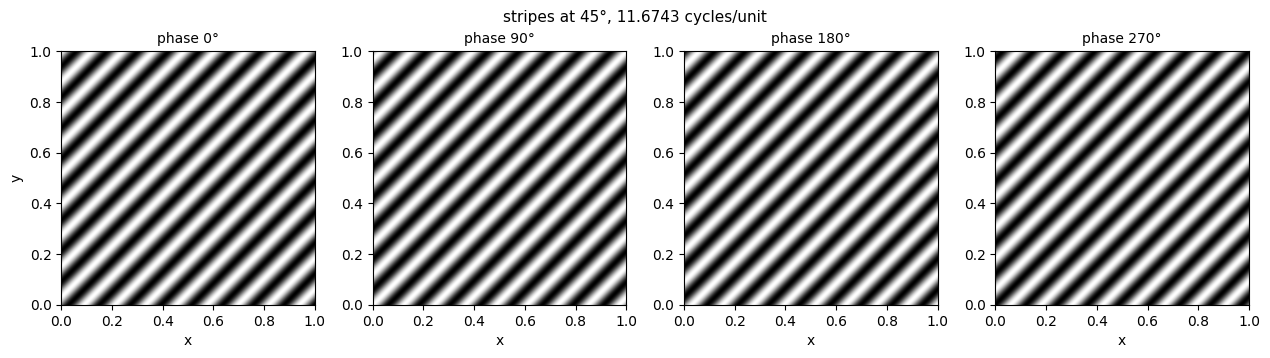

In [11]:
#############################
#       Analytical RF       #
#############################

coords = [0.75,0.75]
target_x, target_y = 0.75, 0.75
target_theta = np.radians(45)
print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")


spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=10)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0

print(f"L1 index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

A_0 = np.full(N_L0_E, 0.5)
spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

best_sf, best_peak, best_L1 = None, -np.inf, None

for sf in sfs:
    resp_L1 = np.zeros(n_phase)

    for i, phase in enumerate(phases):
        A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
        A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
        resp_L1[i] = A_1[target_idx]

    L1 = f1_f0(resp_L1, spont_L1)
    print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

    if L1['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L1['peak'], L1


kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
      f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

Index: 1
Location: x=0.500, y=0.500
Preferred Orientation: 135.0°



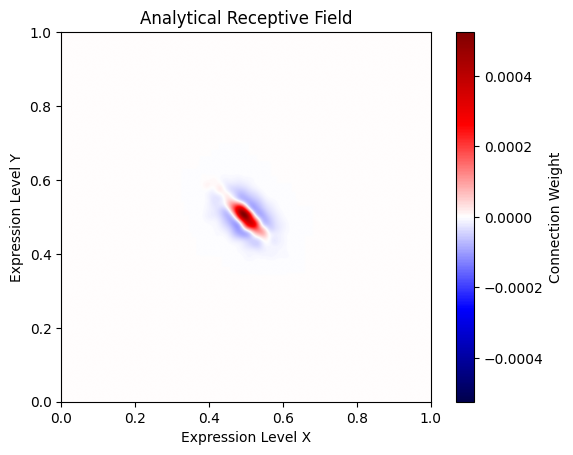

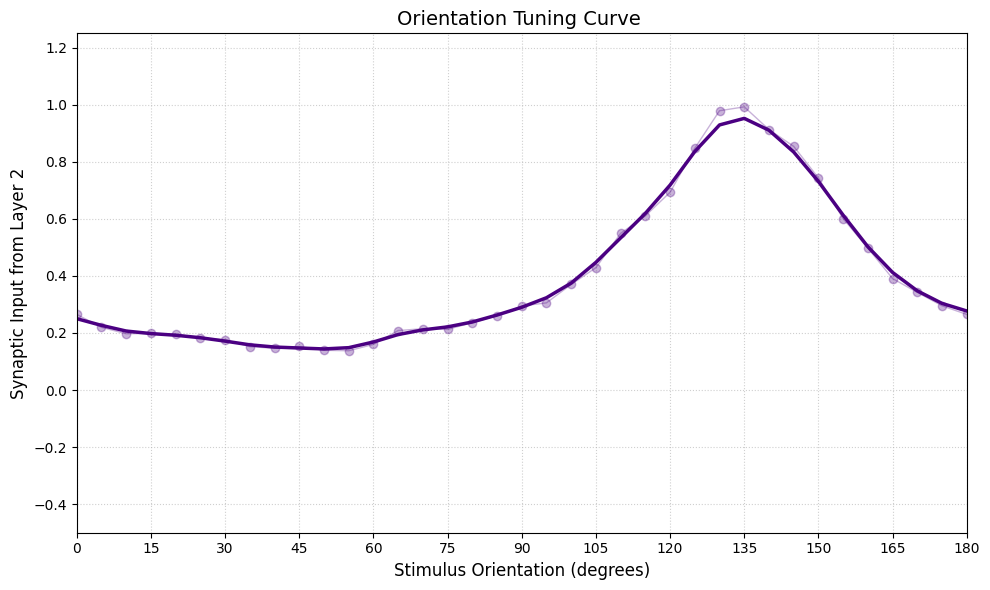

L1 index: 1
Location: x=0.500, y=0.500
Preferred Orientation: 135.0°

sf =   2.00 cyc/unit   L1 F1/F0 =  5.299
sf =   2.35 cyc/unit   L1 F1/F0 =  4.212
sf =   2.76 cyc/unit   L1 F1/F0 =  3.466
sf =   3.24 cyc/unit   L1 F1/F0 =  2.940
sf =   3.80 cyc/unit   L1 F1/F0 =  2.581
sf =   4.46 cyc/unit   L1 F1/F0 =  2.332
sf =   5.24 cyc/unit   L1 F1/F0 =  2.153
sf =   6.15 cyc/unit   L1 F1/F0 =  2.029
sf =   7.22 cyc/unit   L1 F1/F0 =  1.945
sf =   8.47 cyc/unit   L1 F1/F0 =  1.889
sf =   9.94 cyc/unit   L1 F1/F0 =  1.857
sf =  11.67 cyc/unit   L1 F1/F0 =  1.844
sf =  13.71 cyc/unit   L1 F1/F0 =  1.851
sf =  16.09 cyc/unit   L1 F1/F0 =  1.881
sf =  18.89 cyc/unit   L1 F1/F0 =  1.942
sf =  22.17 cyc/unit   L1 F1/F0 =  2.057
sf =  26.03 cyc/unit   L1 F1/F0 =  2.330
sf =  30.56 cyc/unit   L1 F1/F0 =  3.312
sf =  35.88 cyc/unit   L1 F1/F0 =  7.644
sf =  42.12 cyc/unit   L1 F1/F0 =  7.487
sf =  49.45 cyc/unit   L1 F1/F0 =  6.757
sf =  58.05 cyc/unit   L1 F1/F0 =  7.260
sf =  68.15 cyc/unit   L1 F1

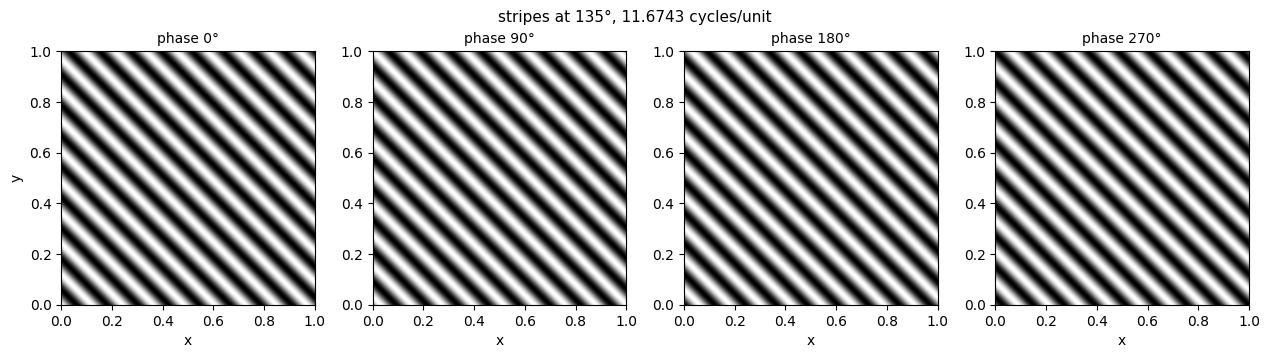

In [7]:
#############################
#       Analytical RF       #
#############################

coords = [0.5,0.5]
target_x, target_y = 0.50, 0.50
target_theta = np.radians(135)
print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")


spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=10)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0

print(f"L1 index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

A_0 = np.full(N_L0_E, 0.5)
spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

best_sf, best_peak, best_L1 = None, -np.inf, None

for sf in sfs:
    resp_L1 = np.zeros(n_phase)

    for i, phase in enumerate(phases):
        A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
        A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
        resp_L1[i] = A_1[target_idx]

    L1 = f1_f0(resp_L1, spont_L1)
    print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

    if L1['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L1['peak'], L1


kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
      f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

In [12]:
# # #############################
# # #        Find RWA RF        #
# # #############################

# W0_full    = (W_0_E + W_0_I).tocsr()
# center_idx = 1                                       # which L1 cell: 0, 1 or 2

# n_frames = 100000
# batch    = 4096
# rng      = np.random.default_rng(0)

# supp = np.unique(W0_full.tocsc().indices)            # inputs with nonzero weight
# Ws   = W0_full[supp].toarray()                       # (n_supp, N_L1_E)

# acc = np.zeros(supp.size)

# for start in range(0, n_frames, batch):
#     print(f'progress at {start}')
#     b    = min(batch, n_frames - start)
#     stim = rng.standard_normal((b, supp.size))
#     A1   = np.maximum(stim @ Ws, 0.0)
#     acts = A1[:, center_idx]
#     acc += acts @ stim

# rwa_total = np.zeros(N_L0_E)
# rwa_total[supp] = acc / n_frames

# rwa_2d = gaussian_filter(rwa_total.reshape(n, n), sigma=5)
# vmax_rwa = np.max(np.abs(rwa_2d))

# fig, ax = plt.subplots()
# im0 = ax.imshow(rwa_2d[::-1, :], cmap='seismic', vmin=-vmax_rwa, vmax=vmax_rwa, extent=[0, 1, 0, 1])
# ax.set_title('RWA Receptive Field')
# ax.set_xlabel('Expression Level X')
# ax.set_ylabel('Expression Level Y')
# plt.colorbar(im0, ax=ax, label='Connection Weight')
# plt.show()

In [13]:
# #############################
# #        Find RWA RF        #
# #############################

# W0_full    = (W_0_E + W_0_I).tocsr()
# center_idx = 0                                       

# W0_dense = np.asarray(W0_full.todense(), dtype=np.float32)   

# n_frames = 30000
# batch    = 256                    
# rng      = np.random.default_rng(0)

# acc = np.zeros(N_L0_E, dtype=np.float64)

# for start in range(0, n_frames, batch):
#     print(f'progress at {start} of {n_frames}')
#     b    = min(batch, n_frames - start)
#     stim = rng.standard_normal((b, N_L0_E), dtype=np.float32)
#     A1   = np.maximum(stim @ W0_dense, np.float32(0))          
#     acts = A1[:, center_idx]
#     acc += (acts @ stim).astype(np.float64)

# rwa_total = acc / n_frames

# rwa_2d = gaussian_filter(rwa_total.reshape(n, n), sigma=1)
# vmax_rwa = np.max(np.abs(rwa_2d))

# fig, ax = plt.subplots()
# im0 = ax.imshow(rwa_2d[::-1, :], cmap='seismic', vmin=-vmax_rwa, vmax=vmax_rwa, extent=[0, 1, 0, 1])
# ax.set_title('RWA Receptive Field')
# ax.set_xlabel('Expression Level X')
# ax.set_ylabel('Expression Level Y')
# plt.colorbar(im0, ax=ax, label='Connection Weight')
# plt.show()

#### Kernel 2: Gabor Filter

##### Option 1: Gaussian Mixture Model

 &emsp; 2.1.1 Build kernel <br>

In [3]:

#############################
#          Params           #
#############################
# np.random.seed(187)

N_L0_E = 1000000
N_L0_I = 1000000
N_L1_E = 3

N = (N_L0_E + N_L0_I, N_L1_E)
n = int((N[0] / 2) ** 0.5)
sig = 1e-4
K = 1
kappa = 50

sig_0_E = 0.01        
sig_0_I = 0.01

n_angles = 2
angles = np.linspace(0, 1, n_angles, endpoint=False) + 0.25
probs = np.full(n_angles, 1 / n_angles)
p_0 = 1

w_0_E =  1.0 / (N_L0_E * (1/len(angles)) * np.pi * (sig_0_E**2) * p_0)
w_0_I = -1.0 / (N_L0_I * (1/len(angles)) * np.pi * (sig_0_I**2) * p_0)

LOBE_SPACING = 0.06

means_E, sx_E, sy_E, w_E = gabor_lobes(n_lobes=3, spacing=LOBE_SPACING,
                                       sx=0.04, sy=sig)
sx_E[[0, 2]] = 0.02      
sy_E[[0, 2]] = sig     
w_E[:] = [0.15, 0.70, 0.15]

means_I, sx_I, sy_I, w_I = gabor_lobes(n_lobes=2, spacing=LOBE_SPACING,
                                       sx=0.03, sy=sig)

#############################
#        Create Net         #
#############################
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
xy_L0_E = np.column_stack((X.ravel(), Y.ravel()))

theta_E = np.random.choice(angles, size=N_L0_E, p=probs) * np.pi
theta_I = np.random.choice(angles, size=N_L0_I, p=probs) * np.pi

layer_lig = xy_L0_E
layer_rec = xy_L0_E.copy()

noise_theta_E = gabor_gmm_noise(N_L0_E, theta_E, means_E, sx_E, sy_E, w_E)
noise_theta_I = gabor_gmm_noise(N_L0_I, theta_I, means_I, sx_I, sy_I, w_I)

rec_E = layer_rec.copy() + noise_theta_E
rec_I = layer_rec.copy() + noise_theta_I

layer_rec_E = np.column_stack((rec_E, theta_E))
layer_rec_I = np.column_stack((rec_I, theta_I))

layer_lig_L0_combined = np.vstack((layer_lig, layer_lig))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

z_E = np.random.rand(N_L1_E, 3)
z_E[:, 2] = np.random.choice(angles, size=N_L1_E, p=probs) * np.pi
z_E[0, 2] = 0.25*np.pi
z_E[1, 2] = 0.75*np.pi
z_E[2, 2] = 0.25*np.pi
z_E[:, 0] = z_E[:, 1] = 0.5
z_E[2, 0] = z_E[2, 1] = 0.75


xy_lig_E = z_E + sig * np.random.randn(N_L1_E, 3)
xy_rec_E = z_E + sig * np.random.randn(N_L1_E, 3)
net.append([xy_lig_E, xy_rec_E])

#############################
#    Create Connectivity    #
#############################
l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]

l_vals_L1_E = net[1][0]
r_vals_L1_E = net[1][1]

B_L0E_L1E = sample_bernoulli_sparse(
    compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E, kappa=kappa), K)
B_L0I_L1E = sample_bernoulli_sparse(
    compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I, kappa=kappa), K)

W_0_E = (w_0_E * B_L0E_L1E).tocsr()
W_0_I = (w_0_I * B_L0I_L1E).tocsr()

 &emsp; 2.1.2 Analyze kernel <br>

Index: 0
Location: x=0.500, y=0.500
Preferred Orientation: 45.0°



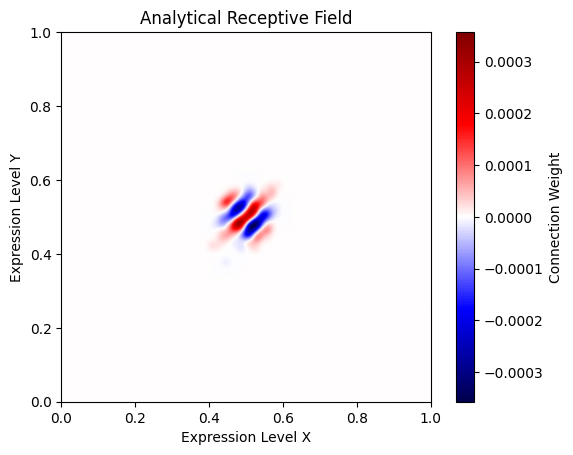

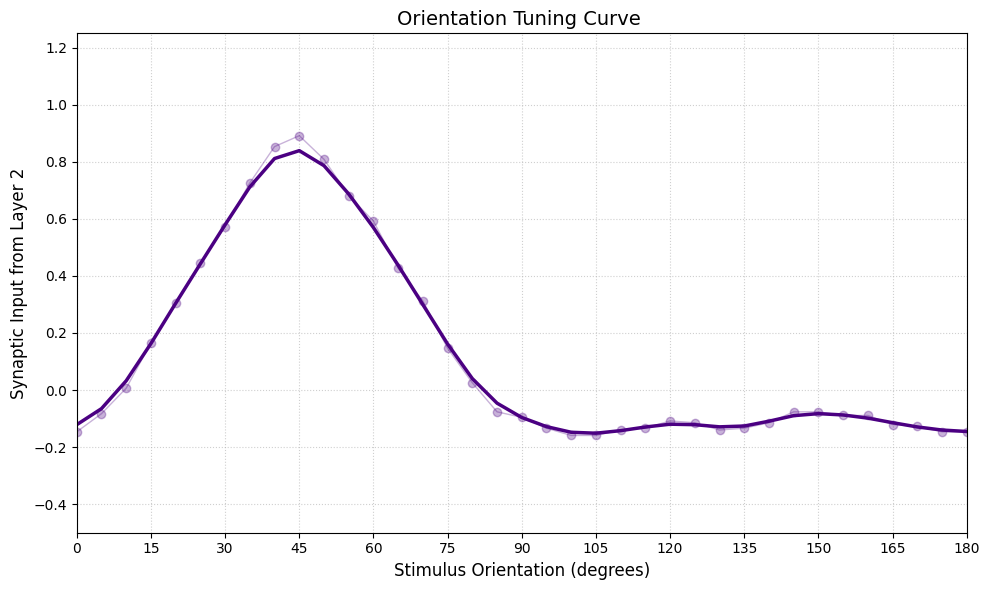

L1 index: 0
Location: x=0.500, y=0.500
Preferred Orientation: 45.0°

sf =   2.00 cyc/unit   L1 F1/F0 =  1.711
sf =   2.35 cyc/unit   L1 F1/F0 =  1.696
sf =   2.76 cyc/unit   L1 F1/F0 =  1.681
sf =   3.24 cyc/unit   L1 F1/F0 =  1.668
sf =   3.80 cyc/unit   L1 F1/F0 =  1.663
sf =   4.46 cyc/unit   L1 F1/F0 =  1.651
sf =   5.24 cyc/unit   L1 F1/F0 =  1.637
sf =   6.15 cyc/unit   L1 F1/F0 =  1.617
sf =   7.22 cyc/unit   L1 F1/F0 =  1.599
sf =   8.47 cyc/unit   L1 F1/F0 =  1.589
sf =   9.94 cyc/unit   L1 F1/F0 =  1.581
sf =  11.67 cyc/unit   L1 F1/F0 =  1.577
sf =  13.71 cyc/unit   L1 F1/F0 =  1.575
sf =  16.09 cyc/unit   L1 F1/F0 =  1.575
sf =  18.89 cyc/unit   L1 F1/F0 =  1.577
sf =  22.17 cyc/unit   L1 F1/F0 =  1.592
sf =  26.03 cyc/unit   L1 F1/F0 =  1.745
sf =  30.56 cyc/unit   L1 F1/F0 =  1.721
sf =  35.88 cyc/unit   L1 F1/F0 =  1.681
sf =  42.12 cyc/unit   L1 F1/F0 =  1.655
sf =  49.45 cyc/unit   L1 F1/F0 =  1.670
sf =  58.05 cyc/unit   L1 F1/F0 =  1.652
sf =  68.15 cyc/unit   L1 F1/

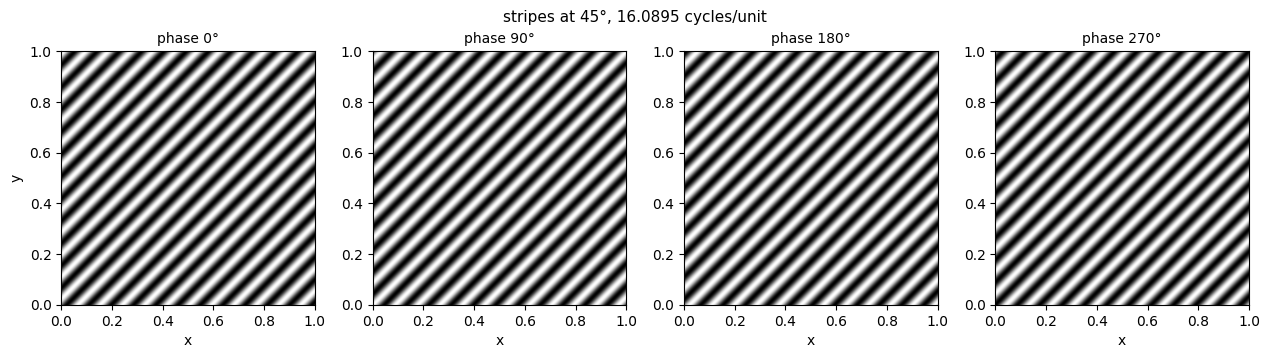

In [4]:
#############################
#       Analytical RF       #
#############################

coords = [0.5,0.5]
target_x, target_y = 0.50, 0.50
target_theta = np.radians(45)

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")

# target_x, target_y = 0.50, 0.50
# spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
# center_idx = np.argmin(spatial_dist)

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=10)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0

print(f"L1 index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

A_0 = np.full(N_L0_E, 0.5)
spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

best_sf, best_peak, best_L1 = None, -np.inf, None

for sf in sfs:
    resp_L1 = np.zeros(n_phase)

    for i, phase in enumerate(phases):
        A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
        A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
        resp_L1[i] = A_1[target_idx]

    L1 = f1_f0(resp_L1, spont_L1)
    print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

    if L1['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L1['peak'], L1


kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
      f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

Index: 1
Location: x=0.500, y=0.500
Preferred Orientation: 135.0°



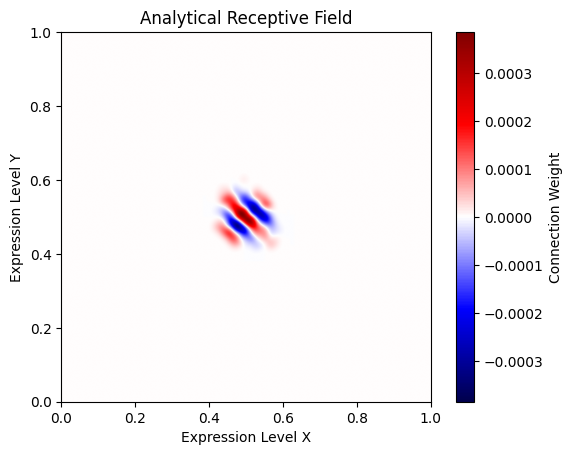

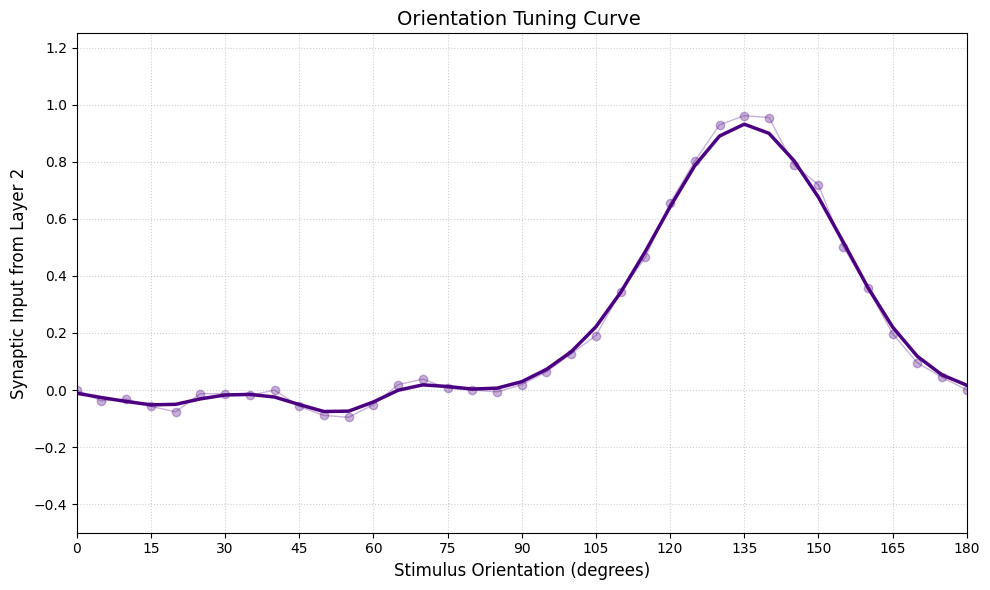

L1 index: 1
Location: x=0.500, y=0.500
Preferred Orientation: 135.0°

sf =   2.00 cyc/unit   L1 F1/F0 = 13.235
sf =   2.35 cyc/unit   L1 F1/F0 = 10.391
sf =   2.76 cyc/unit   L1 F1/F0 =  8.496
sf =   3.24 cyc/unit   L1 F1/F0 =  7.080
sf =   3.80 cyc/unit   L1 F1/F0 =  6.133
sf =   4.46 cyc/unit   L1 F1/F0 =  5.413
sf =   5.24 cyc/unit   L1 F1/F0 =  4.662
sf =   6.15 cyc/unit   L1 F1/F0 =  3.704
sf =   7.22 cyc/unit   L1 F1/F0 =  2.805
sf =   8.47 cyc/unit   L1 F1/F0 =  2.250
sf =   9.94 cyc/unit   L1 F1/F0 =  1.982
sf =  11.67 cyc/unit   L1 F1/F0 =  1.845
sf =  13.71 cyc/unit   L1 F1/F0 =  1.788
sf =  16.09 cyc/unit   L1 F1/F0 =  1.787
sf =  18.89 cyc/unit   L1 F1/F0 =  1.881
sf =  22.17 cyc/unit   L1 F1/F0 =  2.577
sf =  26.03 cyc/unit   L1 F1/F0 = 325.014
sf =  30.56 cyc/unit   L1 F1/F0 =  9.680
sf =  35.88 cyc/unit   L1 F1/F0 = 14.231
sf =  42.12 cyc/unit   L1 F1/F0 = 61.008
sf =  49.45 cyc/unit   L1 F1/F0 =    nan
sf =  58.05 cyc/unit   L1 F1/F0 = 34.820
sf =  68.15 cyc/unit   L1 F

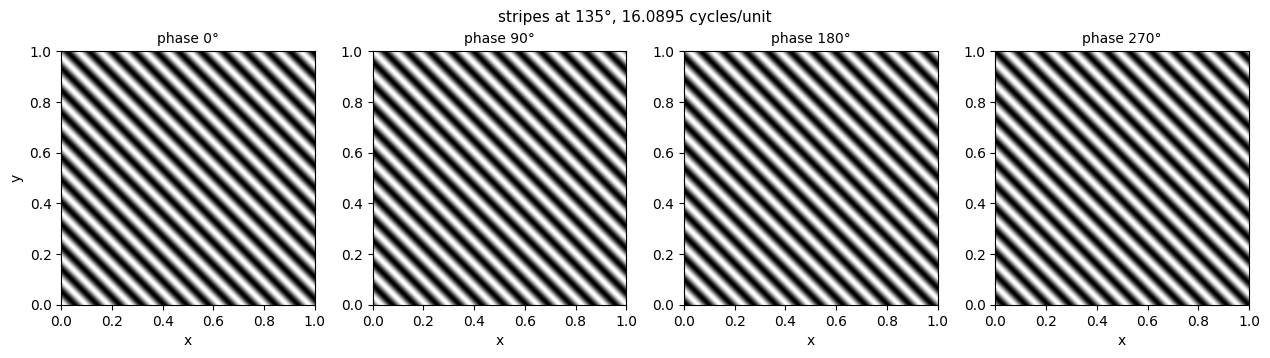

In [5]:
#############################
#       Analytical RF       #
#############################

coords = [0.5,0.5]
target_x, target_y = 0.50, 0.50
target_theta = np.radians(135)

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")

# target_x, target_y = 0.50, 0.50
# spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
# center_idx = np.argmin(spatial_dist)

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=10)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0

print(f"L1 index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

A_0 = np.full(N_L0_E, 0.5)
spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

best_sf, best_peak, best_L1 = None, -np.inf, None

for sf in sfs:
    resp_L1 = np.zeros(n_phase)

    for i, phase in enumerate(phases):
        A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
        A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
        resp_L1[i] = A_1[target_idx]

    L1 = f1_f0(resp_L1, spont_L1)
    print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

    if L1['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L1['peak'], L1


kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
      f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

Index: 2
Location: x=0.750, y=0.750
Preferred Orientation: 45.0°



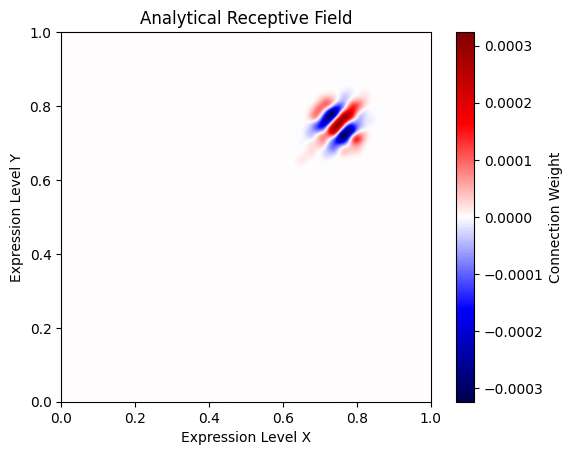

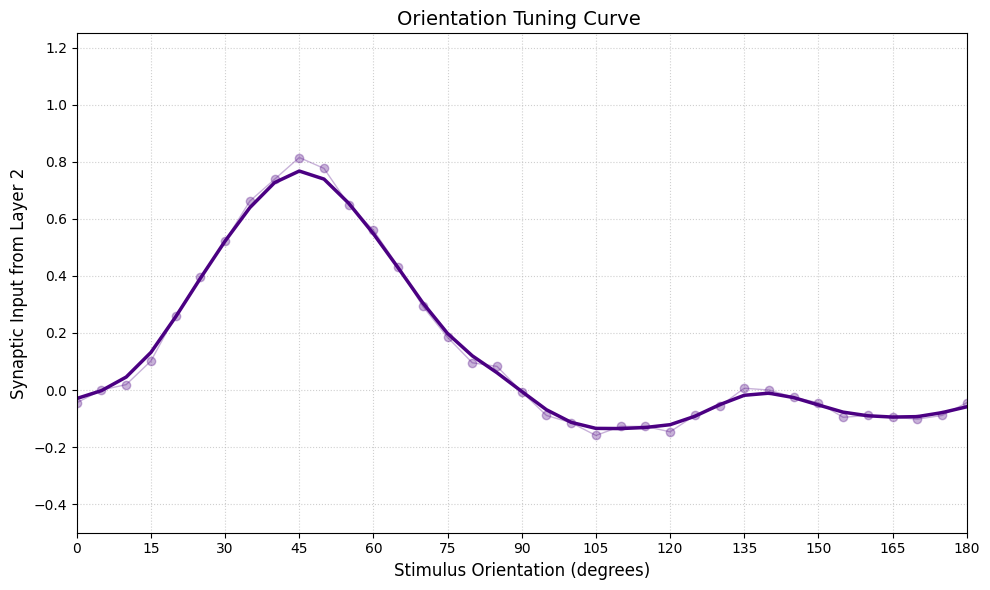

L1 index: 2
Location: x=0.750, y=0.750
Preferred Orientation: 45.0°

sf =   2.00 cyc/unit   L1 F1/F0 =  1.780
sf =   2.35 cyc/unit   L1 F1/F0 =  1.762
sf =   2.76 cyc/unit   L1 F1/F0 =  1.743
sf =   3.24 cyc/unit   L1 F1/F0 =  1.741
sf =   3.80 cyc/unit   L1 F1/F0 =  1.740
sf =   4.46 cyc/unit   L1 F1/F0 =  1.758
sf =   5.24 cyc/unit   L1 F1/F0 =  1.711
sf =   6.15 cyc/unit   L1 F1/F0 =  1.635
sf =   7.22 cyc/unit   L1 F1/F0 =  1.600
sf =   8.47 cyc/unit   L1 F1/F0 =  1.586
sf =   9.94 cyc/unit   L1 F1/F0 =  1.580
sf =  11.67 cyc/unit   L1 F1/F0 =  1.577
sf =  13.71 cyc/unit   L1 F1/F0 =  1.575
sf =  16.09 cyc/unit   L1 F1/F0 =  1.574
sf =  18.89 cyc/unit   L1 F1/F0 =  1.576
sf =  22.17 cyc/unit   L1 F1/F0 =  1.584
sf =  26.03 cyc/unit   L1 F1/F0 =  1.660
sf =  30.56 cyc/unit   L1 F1/F0 =  1.761
sf =  35.88 cyc/unit   L1 F1/F0 =  1.699
sf =  42.12 cyc/unit   L1 F1/F0 =  1.657
sf =  49.45 cyc/unit   L1 F1/F0 =  1.639
sf =  58.05 cyc/unit   L1 F1/F0 =  1.636
sf =  68.15 cyc/unit   L1 F1/

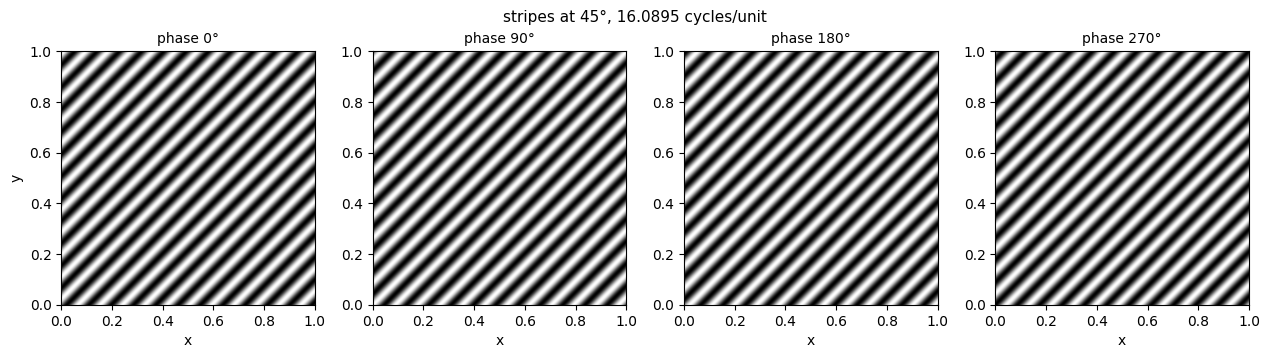

In [6]:
#############################
#       Analytical RF       #
#############################

coords = [0.75,0.75]
target_x, target_y = 0.75, 0.75
target_theta = np.radians(45)

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")

# target_x, target_y = 0.50, 0.50
# spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
# center_idx = np.argmin(spatial_dist)

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=10)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0

print(f"L1 index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

A_0 = np.full(N_L0_E, 0.5)
spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

best_sf, best_peak, best_L1 = None, -np.inf, None

for sf in sfs:
    resp_L1 = np.zeros(n_phase)

    for i, phase in enumerate(phases):
        A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
        A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
        resp_L1[i] = A_1[target_idx]

    L1 = f1_f0(resp_L1, spont_L1)
    print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

    if L1['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L1['peak'], L1


kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
      f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

##### Option 2: Noise from Gabor Filter

 &emsp; 2.2.1 Build kernel <br>

In [12]:

#############################
#          Params           #
#############################
#np.random.seed(seed=187)

N_L0_E = 16000000
N_L0_I = 16000000
N_L1_E = 3

N = (N_L0_E + N_L0_I, N_L1_E)
n = int(N_L0_E ** (1/2))
sig = 0.00001
K = 1

s = 0.5

sig_0_E = 0.010 
sig_0_I = 0.015

kappa = 50

sig_x_E = 0.09 *s       
sig_y_E = 0.05 *s
sig_x_I = 0.09 *s       
sig_y_I = 0.04 *s         
freq    = 11.0 /s      
phase   = 0.0        

n_angles = 2
angles = np.linspace(0, 1, n_angles, endpoint=False) + 0.25
probs = np.full(n_angles, 1/n_angles)

p_0 = 1

w_0_E =  1.0/(N_L0_E*(1/n_angles)*np.pi*((sig_0_E)**2)*p_0) * 5 #2 * 2
w_0_I = -1.0/(N_L0_I*(1/n_angles)*np.pi*((sig_0_I)**2)*p_0) * 5 #2 * 2 

#############################
#        Create Net         #
#############################

net = []

# layer 0

# ext
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
xy_L0_E = np.column_stack((X.ravel(), Y.ravel()))
theta_L0_E = np.random.choice(angles, size=N_L0_E, p=probs) * np.pi

xy_lig_L0_E = xy_L0_E + sig * np.random.randn(N_L0_E, 2)
th_lig_L0_E = theta_L0_E + sig * np.random.randn(N_L0_E)

noise_theta_E = gabor_noise(N_L0_E, theta_L0_E, sig_x_E, sig_y_E, freq, phase)
xy_rec_L0_E = xy_L0_E + noise_theta_E
th_rec_L0_E = theta_L0_E + sig * np.random.randn(N_L0_E)

layer_lig_L0_E = np.column_stack((xy_lig_L0_E, th_lig_L0_E))
layer_rec_L0_E = np.column_stack((xy_rec_L0_E, th_rec_L0_E))

# inh
xy_L0_I = xy_L0_E.copy()
theta_L0_I = np.random.choice(angles, size=N_L0_I, p=probs) * np.pi

xy_lig_L0_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
th_lig_L0_I = theta_L0_I + sig * np.random.randn(N_L0_I)

noise_theta_I = gabor_noise(N_L0_I, theta_L0_I, sig_x_I, sig_y_I, freq=0.0)
xy_rec_L0_I = xy_L0_I + noise_theta_I
th_rec_L0_I = theta_L0_I + sig * np.random.randn(N_L0_I)

layer_lig_L0_I = np.column_stack((xy_lig_L0_I, th_lig_L0_I))
layer_rec_L0_I = np.column_stack((xy_rec_L0_I, th_rec_L0_I))

layer_lig_L0_combined = np.vstack((layer_lig_L0_E, layer_lig_L0_I))
layer_rec_L0_combined = np.vstack((layer_rec_L0_E, layer_rec_L0_I))

net.append([layer_lig_L0_combined, layer_rec_L0_combined])

# layer 1

xy_L1_E = np.random.rand(N_L1_E, 2)
theta_L1_E = np.random.choice(angles, size=N_L1_E, p=probs) * np.pi

theta_L1_E[0] = 0.25*np.pi 
theta_L1_E[1] = 0.75*np.pi 
theta_L1_E[2] = 0.25*np.pi
xy_L1_E[:, 0] = xy_L1_E[:, 1] = 0.5
xy_L1_E[2, 0] = xy_L1_E[2, 1] = 0.75


xy_lig_L1_E = xy_L1_E + sig * np.random.randn(N_L1_E, 2)
th_lig_L1_E = theta_L1_E + sig * np.random.randn(N_L1_E)
layer_lig_L1_E = np.column_stack((xy_lig_L1_E, th_lig_L1_E))

xy_rec_L1_E = xy_L1_E + sig * np.random.randn(N_L1_E, 2)
th_rec_L1_E = theta_L1_E + sig * np.random.randn(N_L1_E)
layer_rec_L1_E = np.column_stack((xy_rec_L1_E, th_rec_L1_E))

net.append([layer_lig_L1_E, layer_rec_L1_E])

#############################
#  Create Connectivity      #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]

l_vals_L1_E = net[1][0]
r_vals_L1_E = net[1][1]

B_L0E_L1E = sample_bernoulli_sparse(
    compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E, kappa=kappa), K)
B_L0I_L1E = sample_bernoulli_sparse(
    compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I, kappa=kappa), K)

W_0_E = (w_0_E * B_L0E_L1E).tocsr()
W_0_I = (w_0_I * B_L0I_L1E).tocsr()

 &emsp; 2.2.2 Analyze kernel <br>

Index: 0
Location: x=0.500, y=0.500
Preferred Orientation: 45.0°



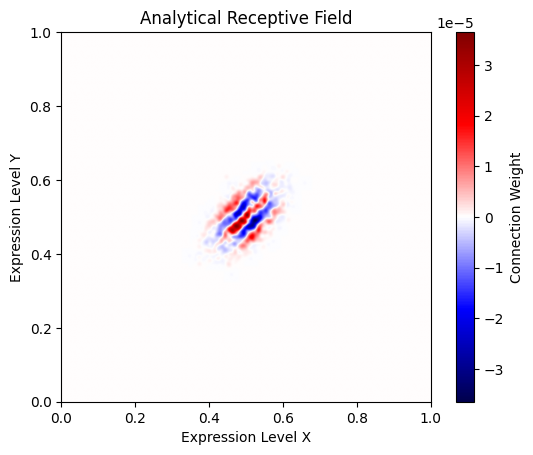

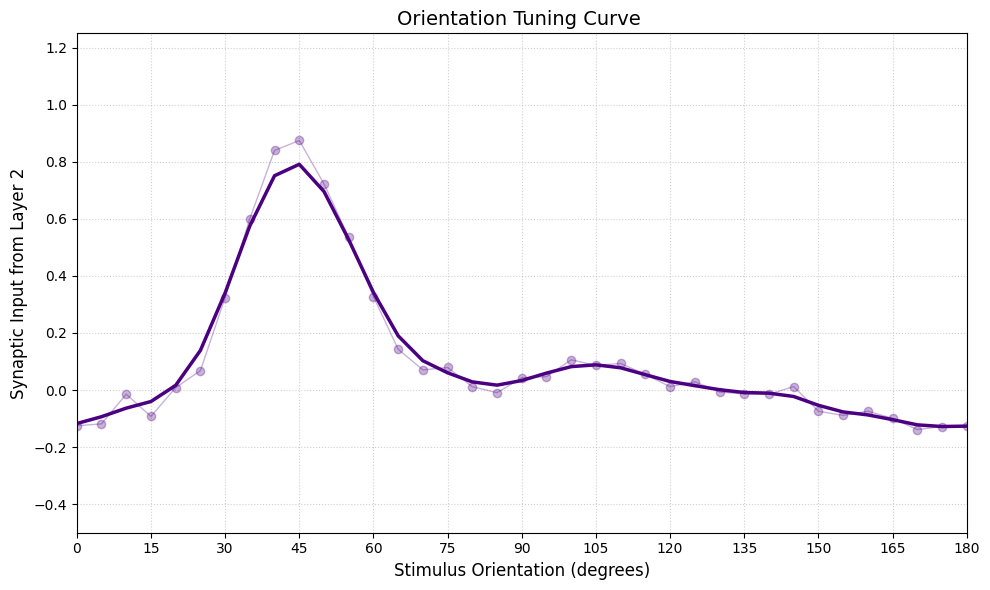

In [11]:
#############################
#       Analytical RF       #
#############################

coords = [0.5,0.5]
target_x, target_y = 0.50, 0.50
target_theta = np.radians(45)

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")

# target_x, target_y = 0.50, 0.50
# spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
# center_idx = np.argmin(spatial_dist)

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=20)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

# n_phase = 32
# phases = np.arange(n_phase) * 2 * np.pi / n_phase
# sfs = np.logspace(np.log10(2), np.log10(80), 24)
# contrast = 1.0

# print(f"L1 index: {target_idx}")
# print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
# print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

# A_0 = np.full(N_L0_E, 0.5)
# spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

# best_sf, best_peak, best_L1 = None, -np.inf, None

# for sf in sfs:
#     resp_L1 = np.zeros(n_phase)

#     for i, phase in enumerate(phases):
#         A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
#         A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
#         resp_L1[i] = A_1[target_idx]

#     L1 = f1_f0(resp_L1, spont_L1)
#     print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

#     if L1['peak'] > best_peak:
#         best_sf, best_peak, best_L1 = sf, L1['peak'], L1


# kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
# print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
# print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
#       f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


# plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
# plt.show()

Index: 2
Location: x=0.750, y=0.750
Preferred Orientation: 45.0°



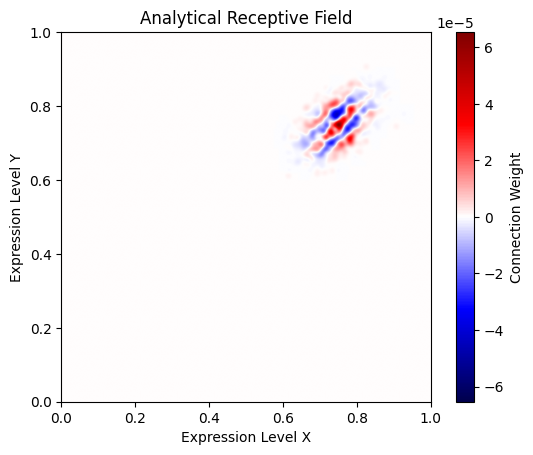

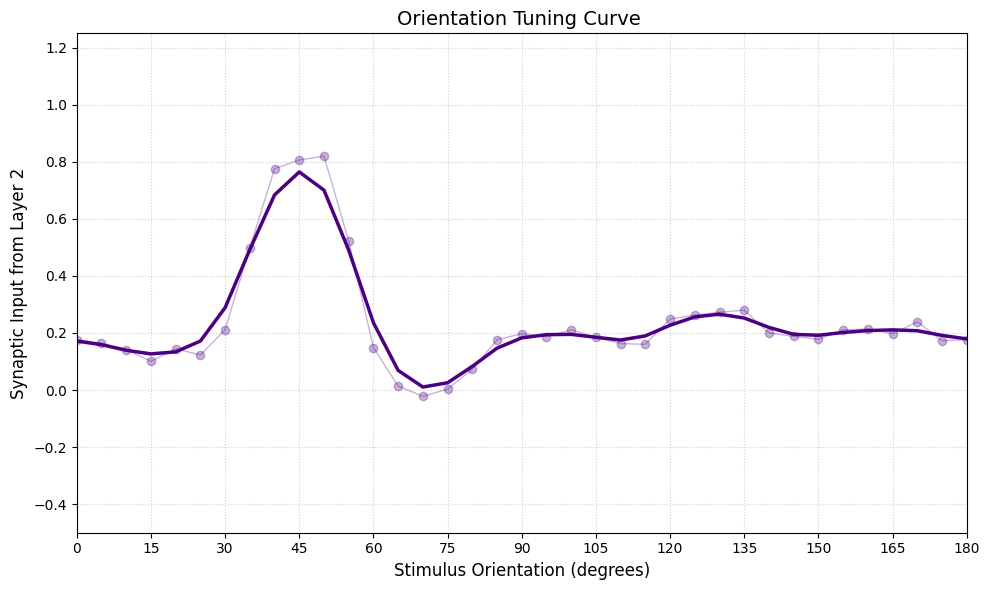

In [9]:
#############################
#       Analytical RF       #
#############################

coords = [0.75,0.75]
target_x, target_y = 0.75, 0.75
target_theta = np.radians(45)

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")

# target_x, target_y = 0.50, 0.50
# spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
# center_idx = np.argmin(spatial_dist)

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=20)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

# n_phase = 32
# phases = np.arange(n_phase) * 2 * np.pi / n_phase
# sfs = np.logspace(np.log10(2), np.log10(80), 24)
# contrast = 1.0

# print(f"L1 index: {target_idx}")
# print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
# print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

# A_0 = np.full(N_L0_E, 0.5)
# spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

# best_sf, best_peak, best_L1 = None, -np.inf, None

# for sf in sfs:
#     resp_L1 = np.zeros(n_phase)

#     for i, phase in enumerate(phases):
#         A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
#         A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
#         resp_L1[i] = A_1[target_idx]

#     L1 = f1_f0(resp_L1, spont_L1)
#     print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

#     if L1['peak'] > best_peak:
#         best_sf, best_peak, best_L1 = sf, L1['peak'], L1


# kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
# print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
# print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
#       f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


# plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
# plt.show()

Index: 1
Location: x=0.500, y=0.500
Preferred Orientation: 135.0°



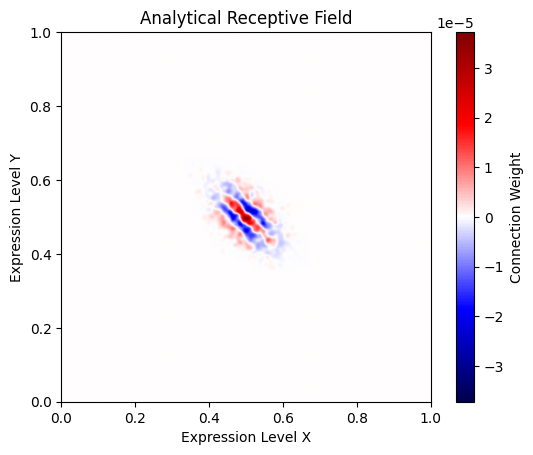

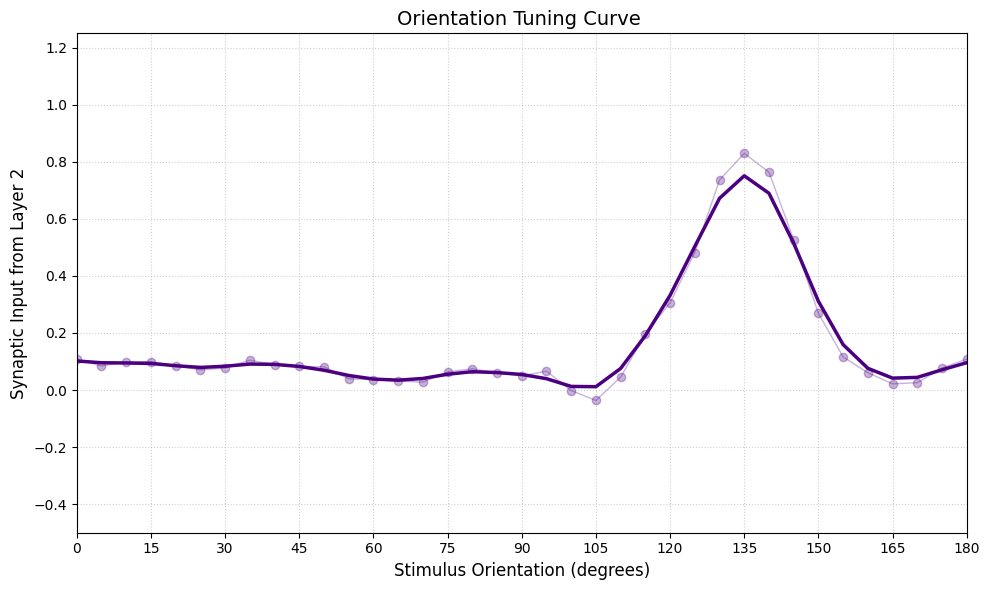

In [13]:
#############################
#       Analytical RF       #
#############################

coords = [0.5,0.5]
target_x, target_y = 0.50, 0.50
target_theta = np.radians(135)

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L1_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}°\n")

# target_x, target_y = 0.50, 0.50
# spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
# center_idx = np.argmin(spatial_dist)

#print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=20)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.2, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = A_1[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

# n_phase = 32
# phases = np.arange(n_phase) * 2 * np.pi / n_phase
# sfs = np.logspace(np.log10(2), np.log10(80), 24)
# contrast = 1.0

# print(f"L1 index: {target_idx}")
# print(f"Location: x={l_vals_L1_E[target_idx, 0]:.3f}, y={l_vals_L1_E[target_idx, 1]:.3f}")
# print(f"Preferred Orientation: {np.degrees(l_vals_L1_E[target_idx, 2]):.1f}\u00b0\n")

# A_0 = np.full(N_L0_E, 0.5)
# spont_L1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)[target_idx]

# best_sf, best_peak, best_L1 = None, -np.inf, None

# for sf in sfs:
#     resp_L1 = np.zeros(n_phase)

#     for i, phase in enumerate(phases):
#         A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
#         A_1 = ReLU(A_0 @ W_0_E + A_0 @ W_0_I)
#         resp_L1[i] = A_1[target_idx]

#     L1 = f1_f0(resp_L1, spont_L1)
#     print(f"sf = {sf:6.2f} cyc/unit   L1 F1/F0 = {L1['ratio']:6.3f}")

#     if L1['peak'] > best_peak:
#         best_sf, best_peak, best_L1 = sf, L1['peak'], L1


# kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
# print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
# print(f"  L1:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
#       f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


# plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
# plt.show()